In [1]:
import tensorflow as tf
from keras.optimizers import Adam
from keras import Sequential, Model
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPool2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.datasets.fashion_mnist import load_data
from keras.utils import to_categorical
from keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import seaborn as sb

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'

---

### 모델 구성 및 학습

In [2]:
modelVgg = VGG16(include_top=False, input_shape=(100,100,3)) # include_top=False -> 분류기 사용 X, 특징 추출기만 있는 층을 가져옴, 분류기는 추가 학습 
modelVgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 100, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 100, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 50, 50, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
dataGen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, vertical_flip=True, 
                            shear_range=0.5, 
                            brightness_range=[0.5,1.5], zoom_range=0.2,
                            width_shift_range=0.1, height_shift_range=0.1,
                            rotation_range=30, fill_mode='nearest' )
imgGen = dataGen.flow_from_directory('C:\빅데이터\deepTest\landscape\seg_train\seg_train', target_size = (100,100))
imgGen.class_indices

Found 14034 images belonging to 6 classes.


{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

In [4]:
model = Sequential()
model.add( modelVgg )
model.add( Flatten())
model.add( Dense(units=64, activation='relu') )
model.add( Dense(units=6, activation='softmax') )
model.compile( loss='categorical_crossentropy', optimizer='adam', metrics=['acc'] )
model.fit( imgGen, epochs=5 )

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 446s 1s/step - acc: 0.3400 - loss: 1.5728
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 1412s 3s/step - acc: 0.5176 - loss: 1.1648
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 1185s 3s/step - acc: 0.5666 - loss: 1.0721
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 1009s 2s/step - acc: 0.6181 - loss: 0.9498
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 427s 967ms/step - acc: 0.6441 - loss: 0.8959


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,030,164 (171.78 MB)

 Trainable params: 15,010,054 (57.26 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 30,020,110 (114.52 MB)

In [6]:
train_dir = r"C:/빅데이터/deepTest/landscape/seg_train/seg_train"
test_dir  = r"C:/빅데이터/deepTest/landscape/seg_test/seg_test"
pred_dir  = r"C:/빅데이터/deepTest/landscape/seg_pred/seg_pred"

In [7]:
train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    train_dir,
    target_size=(100,100),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=(100,100),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # confusion matrix / f1 계산 때문에 반드시 False
)

class_names = list(train_gen.class_indices.keys())
print("클래스 매핑:", train_gen.class_indices)


Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
클래스 매핑: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


---

### train, test : confusion_matrix, accuracy_score, f1_score

In [8]:
history = model.fit(train_gen, epochs=5) 

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 433s 985ms/step - acc: 0.7545 - loss: 0.6633
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 413s 942ms/step - acc: 0.7992 - loss: 0.5481
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 414s 942ms/step - acc: 0.8236 - loss: 0.4941
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 418s 953ms/step - acc: 0.8248 - loss: 0.4857
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 405s 923ms/step - acc: 0.8499 - loss: 0.4275


94/94 ━━━━━━━━━━━━━━━━━━━━ 27s 283ms/step
Test ACC: 0.8293333333333334
Test F1(macro): 0.8288998288114805


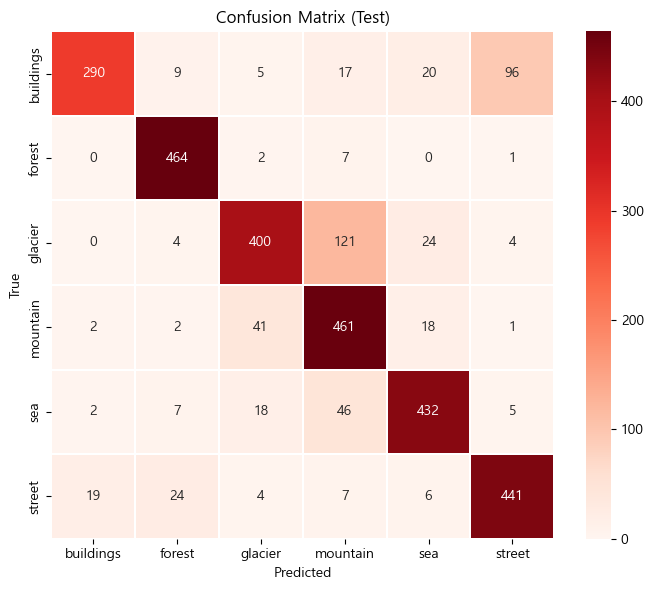

In [9]:
pred_prob = model.predict(test_gen)
y_pred = np.argmax(pred_prob, axis=1)
y_true = test_gen.classes

acc_te = accuracy_score(y_true, y_pred)
f1_te  = f1_score(y_true, y_pred, average='macro')

print("Test ACC:", acc_te)
print("Test F1(macro):", f1_te)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sb.heatmap(cm, annot=True, fmt='d', linewidths=0.3, cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test)")
plt.tight_layout()
plt.show()


Found 14034 images belonging to 6 classes.
Train ACC: 0.8553512897249537
Train F1(macro): 0.8552027077952045


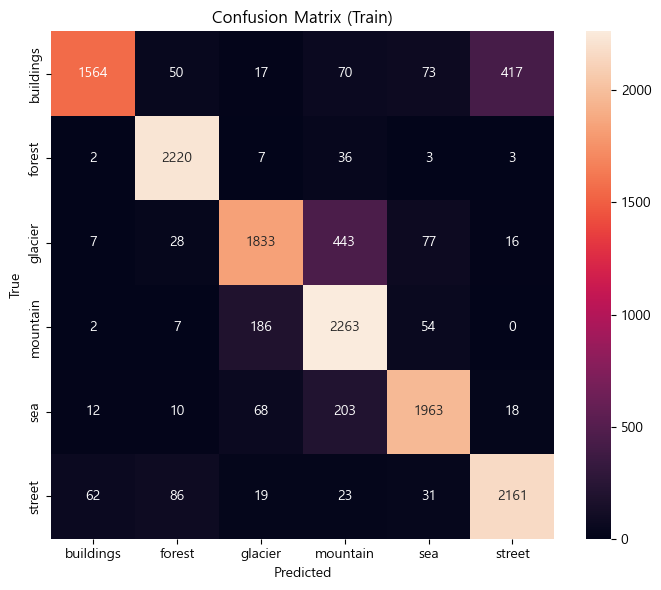

In [10]:
train_eval_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    train_dir,
    target_size=(100,100),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

pred_prob_tr = model.predict(train_eval_gen, steps=len(train_eval_gen), verbose=0)
y_pred_tr = np.argmax(pred_prob_tr, axis=1)
y_true_tr = train_eval_gen.classes

from sklearn.metrics import accuracy_score, f1_score
acc_tr = accuracy_score(y_true_tr, y_pred_tr)
f1_tr  = f1_score(y_true_tr, y_pred_tr, average='macro')

print("Train ACC:", acc_tr)
print("Train F1(macro):", f1_tr)


cm_tr = confusion_matrix(y_true_tr, y_pred_tr)

plt.figure(figsize=(7,6))
sb.heatmap(
    cm_tr,
    annot=True, fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Train)")
plt.tight_layout()
plt.show()

---

### 예측

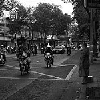

In [11]:
predImg = load_img('C:/빅데이터/deepTest/landscape/seg_pred/seg_pred/3.jpg', target_size=(100,100))
predImg

In [12]:
imgArr = img_to_array(predImg)/255
model.predict(imgArr.reshape(1,100,100,3)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step


array([5])

In [13]:
train_gen.class_indices

{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

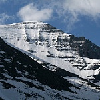

In [14]:
predImg1 = load_img('C:/빅데이터/deepTest/landscape/seg_pred/seg_pred/30.jpg', target_size=(100,100))
predImg1

In [15]:
imgArr = img_to_array(predImg1)/255
model.predict(imgArr.reshape(1,100,100,3)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


array([3])

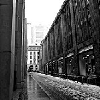

In [16]:
predImg2 = load_img('C:/빅데이터/deepTest/landscape/seg_pred/seg_pred/72.jpg', target_size=(100,100))
predImg2

In [17]:
imgArr = img_to_array(predImg2)/255
model.predict(imgArr.reshape(1,100,100,3)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


array([5])

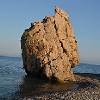

In [18]:
predImg3 = load_img('C:/빅데이터/deepTest/landscape/seg_pred/seg_pred/132.jpg', target_size=(100,100))
predImg3

In [19]:
imgArr = img_to_array(predImg3)/255
model.predict(imgArr.reshape(1,100,100,3)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


array([4])

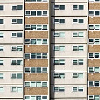

In [20]:
predImg4 = load_img('C:/빅데이터/deepTest/landscape/seg_pred/seg_pred/222.jpg', target_size=(100,100))
predImg4

In [21]:
imgArr = img_to_array(predImg4)/255
model.predict(imgArr.reshape(1,100,100,3)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


array([5])

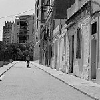

In [22]:
predImg5 = load_img('C:/빅데이터/deepTest/landscape/seg_pred/seg_pred/182.jpg', target_size=(100,100))
predImg5

In [23]:
imgArr = img_to_array(predImg5)/255
model.predict(imgArr.reshape(1,100,100,3)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


array([5])

In [24]:
model.save("model_cpu.keras")